In [22]:
pip install ucimlrepo

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.matlib
import math
import signal
from ucimlrepo import fetch_ucirepo
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
from scipy.spatial.distance import euclidean
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import multivariate_normal
from sklearn import svm
from sklearn import tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, Normalizer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import mutual_info_classif
from scipy.spatial import distance
from scipy.spatial.distance import cdist
from imblearn.over_sampling import SMOTE

Criando banco de dados para demonstrar o uso do método SMOTE

In [42]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_classes=2,
    class_sep=1.25,
    weights=[0.3, 0.7],
    n_informative=2,
    n_redundant=0,
    flip_y=0,
    n_features=2,
    n_clusters_per_class=1,
    n_samples=1000,
    random_state=10,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

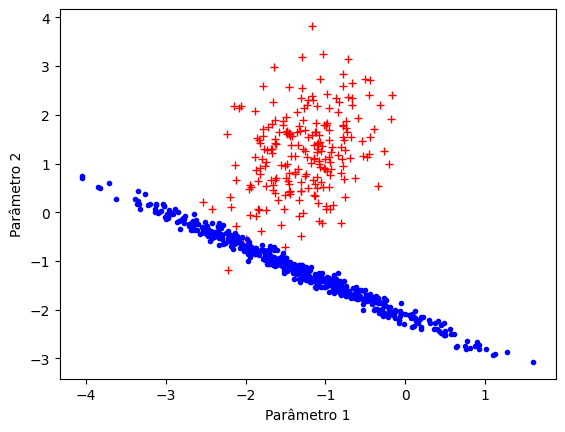

In [43]:
X_trainC1 = X_train[y_train == 0]
X_trainC2 = X_train[y_train == 1]
plt.plot(X_trainC1[:,0], X_trainC1[:,1], 'r+')
plt.plot(X_trainC2[:,0], X_trainC2[:,1], 'b.')
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.show()

In [44]:
X_trainC1.shape

(225, 2)

In [45]:
X_trainC2.shape

(525, 2)

In [46]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(k_neighbors=1, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

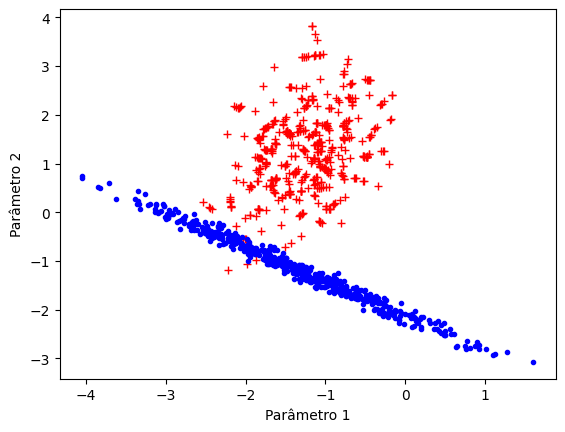

In [47]:
X_trainC1 = X_train_res[y_train_res == 0]
X_trainC2 = X_train_res[y_train_res == 1]
plt.plot(X_trainC1[:,0], X_trainC1[:,1], 'r+')
plt.plot(X_trainC2[:,0], X_trainC2[:,1], 'b.')
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.show()

In [40]:
X_trainC1.shape

(525, 2)

In [41]:
X_trainC2.shape

(525, 2)

Exemplo PCA

In [49]:
X, y = make_classification(
    n_classes=2,
    class_sep=1.25,
    weights=[0.5, 0.5],
    n_informative=3,
    n_redundant=0,
    flip_y=0,
    n_features=3,
    n_clusters_per_class=1,
    n_samples=5000,
    random_state=1,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

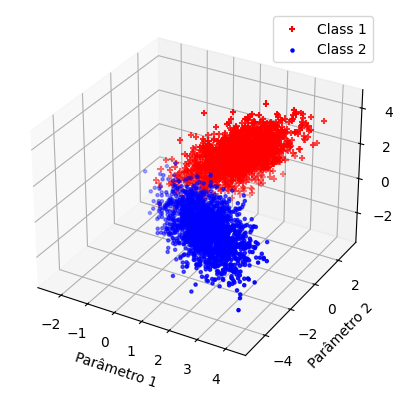

In [50]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

X_train_C1 = X_train[y_train == 0]
X_train_C2 = X_train[y_train == 1]

ax.scatter(X_train_C1[:, 0], X_train_C1[:, 1], X_train_C1[:, 2], c='r', marker='+', label='Class 1')
ax.scatter(X_train_C2[:, 0], X_train_C2[:, 1], X_train_C2[:, 2], c='b', marker='.', label='Class 2')

ax.set_xlabel('Parâmetro 1')
ax.set_ylabel('Parâmetro 2')
ax.set_zlabel('Parâmetro 3')
ax.legend()

plt.show()

In [52]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)

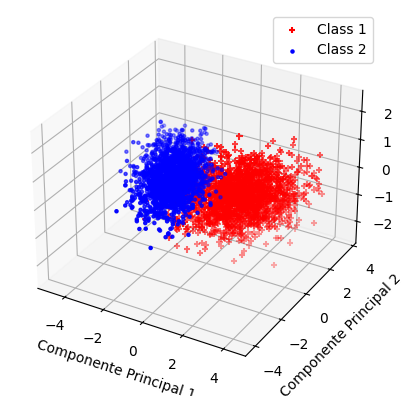

In [53]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

X_train_pca_C1 = X_train_pca[y_train == 0]
X_train_pca_C2 = X_train_pca[y_train == 1]

ax.scatter(X_train_pca_C1[:, 0], X_train_pca_C1[:, 1], X_train_pca_C1[:, 2], c='r', marker='+', label='Class 1')
ax.scatter(X_train_pca_C2[:, 0], X_train_pca_C2[:, 1], X_train_pca_C2[:, 2], c='b', marker='.', label='Class 2')

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.legend()

plt.show()

In [54]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

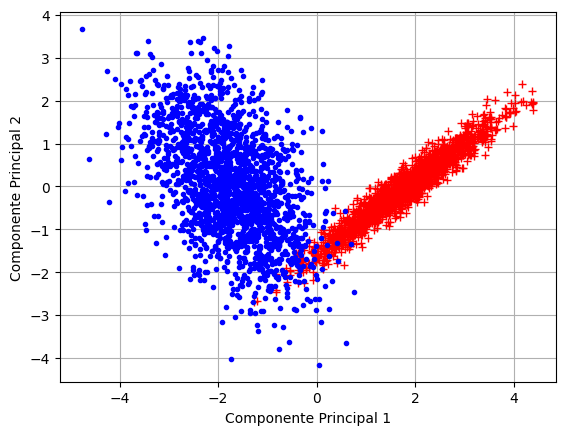

In [55]:
X_trainC1 = X_train_pca[y_train == 0]
X_trainC2 = X_train_pca[y_train == 1]
plt.plot(X_trainC1[:,0], X_trainC1[:,1], 'r+')
plt.plot(X_trainC2[:,0], X_trainC2[:,1], 'b.')
plt.grid()
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

Exemplo de mais fácil visualização

In [56]:
np.random.seed(2)
sigma1 = np.array([[1, 0.5],
          [0.5, 1]])
sigma2 = sigma1
mu1 = np.array([-4, 4])
mu2 = np.array([4, -4])
C1 = np.random.multivariate_normal(mu1, sigma1, 10000)
C2 = np.random.multivariate_normal(mu2, sigma2, 10000)

In [57]:
X = np.concatenate((C1, C2))
y = np.concatenate((np.zeros(10000), np.ones(10000)))

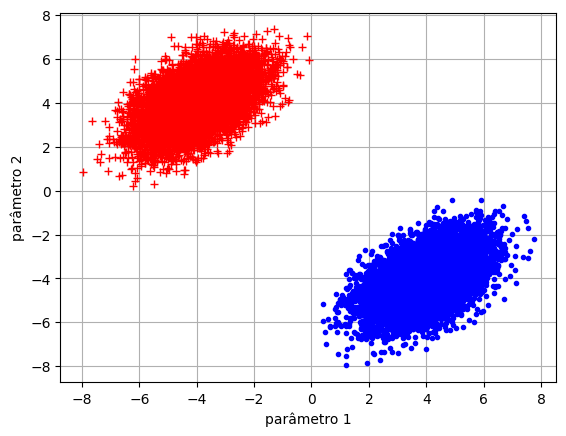

In [58]:
X_C1 = X[y == 0]
X_C2 = X[y == 1]
plt.plot(X_C1[:,0], X_C1[:,1], 'r+')
plt.plot(X_C2[:,0], X_C2[:,1], 'b.')
plt.grid()
plt.xlabel("parâmetro 1")
plt.ylabel("parâmetro 2")
plt.show()

In [59]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

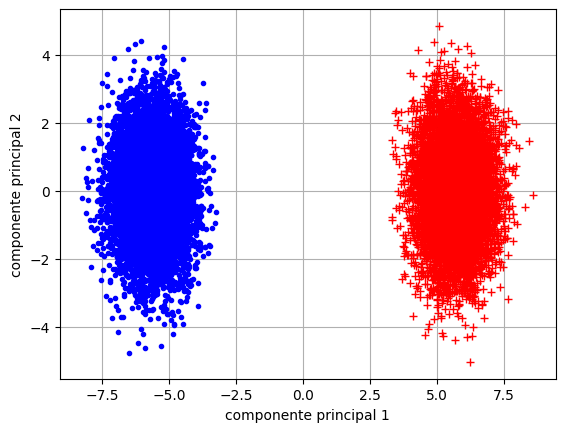

In [60]:
X_pcaC1 = X_pca[y == 0]
X_pcaC2 = X_pca[y == 1]
plt.plot(X_pcaC1[:,0], X_pcaC1[:,1], 'r+')
plt.plot(X_pcaC2[:,0], X_pcaC2[:,1], 'b.')
plt.grid()
plt.xlabel("componente principal 1")
plt.ylabel("componente principal 2")
plt.show()

Normalização

In [ ]:
X, y = make_classification(
    n_classes=2,
    class_sep=1.25,
    weights=[0.3, 0.7],
    n_informative=2,
    n_redundant=0,
    flip_y=0,
    n_features=2,
    n_clusters_per_class=1,
    n_samples=5000,
    random_state=10,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=43)

In [ ]:
X_trainC1 = X_train[y_train == 0]
X_trainC2 = X_train[y_train == 1]
plt.plot(X_trainC1[:,0], X_trainC1[:,1], 'r+')
plt.plot(X_trainC2[:,0], X_trainC2[:,1], 'b.')
plt.grid()
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_trainC1 = X_train_scaled[y_train == 0]
X_trainC2 = X_train_scaled[y_train == 1]
plt.plot(X_trainC1[:,0], X_trainC1[:,1], 'r+')
plt.plot(X_trainC2[:,0], X_trainC2[:,1], 'b.')
plt.grid()
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_trainC1 = X_train_scaled[y_train == 0]
X_trainC2 = X_train_scaled[y_train == 1]
plt.plot(X_trainC1[:,0], X_trainC1[:,1], 'r+')
plt.plot(X_trainC2[:,0], X_trainC2[:,1], 'b.')
plt.grid()
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.show()

In [ ]:
np.mean(X_train_scaled, axis=0)

In [ ]:
np.std(X_train_scaled, axis=0)

In [ ]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_trainC1 = X_train_scaled[y_train == 0]
X_trainC2 = X_train_scaled[y_train == 1]
plt.plot(X_trainC1[:,0], X_trainC1[:,1], 'r+')
plt.plot(X_trainC2[:,0], X_trainC2[:,1], 'b.')
plt.grid()
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.show()

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_classes=2,
    class_sep=1,
    weights=[0.5, 0.5],
    n_informative=2,
    n_redundant=0,
    flip_y=0,
    n_features=2,
    n_clusters_per_class=1,
    n_samples=1000,
    random_state=20,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [ ]:
X_trainC1 = X_train[y_train == 0]
X_trainC2 = X_train[y_train == 1]
plt.plot(X_trainC1[:,0], X_trainC1[:,1], 'r+')
plt.plot(X_trainC2[:,0], X_trainC2[:,1], 'b.')
plt.grid()
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.show()

In [ ]:
clf=MLPClassifier(hidden_layer_sizes=(1,),activation='tanh', random_state=10, max_iter=40000).fit(X_train, y_train)
y_pred = clf.predict(X_test)
Eficiencia = accuracy_score(y_test, y_pred)*100
#print("Eficiência:", Eficiencia)
print(confusion_matrix(y_test, y_pred))

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label='Curva ROC (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_classes=4,
    class_sep=1,
    weights=[1/4, 1/4, 1/4, 1/4],
    n_informative=2,
    n_redundant=0,
    flip_y=0,
    n_features=2,
    n_clusters_per_class=1,
    n_samples=1000,
    random_state=30,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [ ]:
X_trainC1 = X_train[y_train == 0]
X_trainC2 = X_train[y_train == 1]
X_trainC3 = X_train[y_train == 2]
X_trainC4 = X_train[y_train == 3]

plt.plot(X_trainC1[:, 0], X_trainC1[:, 1], 'r+', label='Classe 1')
plt.plot(X_trainC2[:, 0], X_trainC2[:, 1], 'b.', label='Classe 2')
plt.plot(X_trainC3[:, 0], X_trainC3[:, 1], 'g*', label='Classe 3')
plt.plot(X_trainC4[:, 0], X_trainC4[:, 1], 'mX', label='Classe 4')

plt.grid()
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.title("Distribuição das Classes no Espaço de Parâmetros")
plt.legend()
plt.show()


In [ ]:
clf=MLPClassifier(hidden_layer_sizes=(4,),activation='tanh', random_state=10, max_iter=40000).fit(X_train, y_train)
y_pred = clf.predict(X_test)
Eficiencia = accuracy_score(y_test, y_pred)*100
#print("Eficiência:", Eficiencia)
print(confusion_matrix(y_test, y_pred))

[[57  0  6  0]
 [ 2 57  3  0]
 [ 1  0 62  0]
 [ 0  3  1 58]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93        63
           1       0.95      0.92      0.93        62
           2       0.86      0.98      0.92        63
           3       1.00      0.94      0.97        62

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

